# 🛒 Notebook 02 — Olist Billing Leakage Analysis

---

## 🏢 Business Context

In e-commerce, every order passes through a multi-step payment pipeline — items are priced, freight is calculated, and payment is collected through one or more payment methods (credit card, voucher, boleto, etc.). When the amount actually collected does not match what was expected based on order and freight values, the difference represents a **billing gap**.

At scale, even small per-order payment shortfalls can accumulate into significant revenue leakage — especially in platforms handling hundreds of thousands of orders. This notebook investigates billing reconciliation gaps using the **Olist Brazilian E-Commerce dataset**, one of the most detailed public e-commerce transaction datasets available.

---

## ❗ Business Problem Statement

> *"The finance team has flagged unexplained differences between expected order revenue (product value + freight) and the payment amounts actually received and recorded. Without a systematic reconciliation framework, it is impossible to determine whether these gaps represent processing errors, fraud, incomplete payment captures, or instalment shortfalls."*

**Core questions this notebook answers:**
1. For how many orders does the total payment collected fall short of the expected amount (product value + freight)?
2. What is the total cumulative billing gap across all flagged orders?
3. Are billing gaps concentrated in specific order statuses or payment configurations?
4. Which individual orders represent the largest reconciliation risk?

---

## 🎯 Objectives

| # | Objective | Type |
|---|---|---|
| 1 | Merge orders, items, and payments tables into a single analytical master table | Data Engineering |
| 2 | Compute expected payment per order (item value + freight) | Feature Engineering |
| 3 | Calculate payment gap = expected − actual received | Leakage Detection |
| 4 | Flag orders where gap exceeds the noise threshold (> $1) | Quantification |
| 5 | Analyse gap distribution by order status and payment type | Segmentation |
| 6 | Identify top orders with the largest reconciliation gaps | Prioritisation |
| 7 | Export the billing analysis table to SQLite | Data Engineering |

---

## 📂 Dataset

| Property | Detail |
|---|---|
| **Name** | Olist Brazilian E-Commerce Public Dataset |
| **Source** | Kaggle — [Olist Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) |
| **Format** | Multiple CSVs |
| **Geography** | Brazil |
| **Time Period** | 2016 – 2018 |

**Tables used in this notebook:**

| Table | Rows (approx.) | Key Columns |
|---|---|---|
| `olist_orders_dataset.csv` | ~99,441 | `order_id`, `order_status`, `order_delivered_customer_date` |
| `olist_order_items_dataset.csv` | ~112,650 | `order_id`, `price`, `freight_value` |
| `olist_order_payments_dataset.csv` | ~103,886 | `order_id`, `payment_value`, `payment_type`, `payment_installments` |

---

## 🔬 Methodology

```
3 RAW TABLES
    │
    ▼
DATA AUDIT          → Nulls, duplicates, order_id uniqueness check
    │
    ▼
AGGREGATION
    ├── items_agg:    GROUP BY order_id → SUM(price), SUM(freight), COUNT(items)
    └── payments_agg: GROUP BY order_id → SUM(payment_value), MAX(installments)
    │
    ▼
MASTER TABLE MERGE
    orders LEFT JOIN items_agg LEFT JOIN payments_agg ON order_id
    │
    ▼
NULL HANDLING       → Fill financial nulls with 0 (prevents NaN propagation)
    │
    ▼
FEATURE ENGINEERING
    expected_payment = total_order_value + total_freight_value
    payment_gap      = expected_payment − total_payment_value
    │
    ▼
LEAKAGE FLAGGING    → Flag:   payment_gap > 1  (noise threshold)
                       Amount: payment_gap for flagged orders
    │
    ▼
ANALYSIS            → By order_status, payment_type, installments
    │
    ▼
SQLITE EXPORT       → Table: olist_billing_analysis
```

---

## 📏 Scope

**In Scope:**
- Payment reconciliation gap between expected and received amounts
- All order statuses included (delivered, cancelled, invoiced, etc.)
- Billing leakage only — no return or pricing analysis

**Out of Scope:**
- Instalment default risk modelling
- Fraud detection on payment methods
- Currency conversion (values are in BRL)
- Seller-side payment disbursement analysis

---

## 📤 Deliverables

| Deliverable | Description |
|---|---|
| `olist_billing_analysis` table | Master merged table with billing leakage flags stored in `revenue_leakage.db` |
| `payment_gap` column | Per-order difference between expected and actual payment |
| `Billing Leakage Flag` column | Binary flag — 1 if gap > $1 |
| `Billing Leakage Amount` column | Leakage amount for flagged orders |
| Segmentation summary | Leakage breakdown by order_status and payment configuration |

---

## ⚠️ Assumptions & Limitations

| # | Assumption / Limitation |
|---|---|
| 1 | `payment_gap > $1` threshold is used to exclude floating-point rounding noise from payment processors — not all gaps are genuine leakage |
| 2 | Cancelled and non-delivered orders are included; some gaps may represent legitimate refunds or cancellation adjustments rather than true leakage |
| 3 | Multiple payment types per order are aggregated by sum — split-payment combinations (e.g., credit card + voucher) are treated as a single expected total |
| 4 | Monetary values are in Brazilian Real (BRL), not USD |
| 5 | Without access to Olist's internal refund and voucher logs, distinguishing genuine billing gaps from authorised adjustments is not possible with this dataset alone |

---

## 📋 Notebook Structure

1. Library Imports & Setup
2. Data Loading (3 tables)
3. Dataset Audit — Orders, Items, Payments
4. Aggregation — Items & Payments
5. Master Table Merge
6. Null Handling
7. Feature Engineering (Expected Payment, Payment Gap)
8. Billing Leakage Flagging & Quantification
9. Segmentation Analysis (by Status, Payment Type, Installments)
10. Top Leakage Cases
11. Visualisation
12. SQLite Export

---

| | |
|---|---|
| **Author** | Abhiram |
| **Project** | Revenue Leakage Intelligence System |
| **Notebook** | 02 of 04 |
| **Dataset** | Olist Brazilian E-Commerce (Kaggle) |
| **Output Table** | `olist_billing_analysis` → `revenue_leakage.db` |

In [1]:
# ==============================
# BASIC SETUP
# ==============================

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# ==============================
# DATA HANDLING
# ==============================

import pandas as pd
import numpy as np

# ==============================
# DATABASE
# ==============================

import sqlite3

# ==============================
# VISUALIZATION
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns


# Seaborn theme
sns.set_style("whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ==============================
# LOAD DATASETS
# ==============================

# OLIST DATASETS
orders = pd.read_csv("../Data/Raw_Data/olist_orders_dataset.csv")

items = pd.read_csv("../Data/Raw_Data/olist_order_items_dataset.csv")

payments = pd.read_csv("../Data/Raw_Data/olist_order_payments_dataset.csv")

In [3]:
# ==============================
# QUICK DATASET CHECK
# ==============================
print("ORDERS SHAPE     :", orders.shape)
print("ITEMS SHAPE      :", items.shape)
print("PAYMENTS SHAPE   :", payments.shape)

ORDERS SHAPE     : (99441, 8)
ITEMS SHAPE      : (112650, 7)
PAYMENTS SHAPE   : (103886, 5)


In [4]:
# ==============================
# ORDERS DATASET AUDIT
# ==============================

print("=" * 50)
print("ORDERS DATASET")
print("=" * 50)

# Shape
print("\nSHAPE:\n")
print(orders.shape)

# Columns
print("\nCOLUMNS:\n")
print(orders.columns)

# Datatypes
print("\nDATATYPES:\n")
print(orders.dtypes)

# Null Values
print("\nNULL VALUES:\n")
print(orders.isnull().sum())

# Duplicates
print("\nDUPLICATES:\n")
print(orders.duplicated().sum())

ORDERS DATASET

SHAPE:

(99441, 8)

COLUMNS:

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

DATATYPES:

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

NULL VALUES:

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

DUPLICATES:

0


In [6]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
# ==============================
# ORDER STATUS DISTRIBUTION
# ==============================

orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [8]:
# ==============================
# NULL DELIVERY ANALYSIS
# ==============================

orders[
    orders["order_delivered_customer_date"].isnull()
]["order_status"].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

In [9]:
# ==============================
# ORDER ID UNIQUENESS
# ==============================

print(
    "Orders unique order_id:",
    orders["order_id"].nunique()
)

print(
    "Orders total rows:",
    len(orders)
)

Orders unique order_id: 99441
Orders total rows: 99441


In [10]:
# ==============================
# ITEMS DATASET AUDIT
# ==============================

print("=" * 50)
print("ITEMS DATASET")
print("=" * 50)

print("\nSHAPE:\n")
print(items.shape)

print("\nCOLUMNS:\n")
print(items.columns)

print("\nDATATYPES:\n")
print(items.dtypes)

print("\nNULL VALUES:\n")
print(items.isnull().sum())

print("\nDUPLICATES:\n")
print(items.duplicated().sum())

ITEMS DATASET

SHAPE:

(112650, 7)

COLUMNS:

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

DATATYPES:

order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

NULL VALUES:

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

DUPLICATES:

0


In [20]:
# ==============================
# PAYMENTS DATASET AUDIT
# ==============================

print("=" * 50)
print("PAYMENTS DATASET")
print("=" * 50)

print("\nSHAPE:\n")
print(payments.shape)

print("\nCOLUMNS:\n")
print(payments.columns)

print("\nDATATYPES:\n")
print(payments.dtypes)

print("\nNULL VALUES:\n")
print(payments.isnull().sum())

print("\nDUPLICATES:\n")
print(payments.duplicated().sum())

PAYMENTS DATASET

SHAPE:

(103886, 5)

COLUMNS:

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

DATATYPES:

order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

NULL VALUES:

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

DUPLICATES:

0


In [21]:
# ==============================
# MULTIPLE PAYMENTS CHECK
# ==============================

payment_counts = (
    payments["order_id"]
    .value_counts()
)

payment_counts.describe()

count    99440.000000
mean         1.044710
std          0.381166
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         29.000000
Name: count, dtype: float64

In [29]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [32]:
# ==============================
# ITEMS AGGREGATION
# ==============================

items_agg = (
    items
    .groupby("order_id")
    .agg({
        "price": "sum",
        "freight_value": "sum",
        "order_item_id": "count"
    })
    .reset_index()
)

# Rename columns
items_agg.rename(
    columns={
        "price": "total_order_value",
        "freight_value": "total_freight_value",
        "order_item_id": "total_items"
    },
    inplace=True
)

items_agg.head()

,order_id,total_order_value,total_freight_value,total_items
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1


In [33]:
# ==============================
# PAYMENTS AGGREGATION
# ==============================

payments_agg = (
    payments
    .groupby("order_id")
    .agg({
        "payment_value": "sum",
        "payment_installments": "max",
        "payment_type": "nunique"
    })
    .reset_index()
)

# Rename columns
payments_agg.rename(
    columns={
        "payment_value": "total_payment_value",
        "payment_installments": "max_installments",
        "payment_type": "unique_payment_types"
    },
    inplace=True
)

payments_agg.head()

,order_id,total_payment_value,max_installments,unique_payment_types
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1


In [34]:
# ==============================
# AGGREGATION VALIDATION
# ==============================

print("Items Aggregated Shape:")
print(items_agg.shape)

print("\nPayments Aggregated Shape:")
print(payments_agg.shape)

Items Aggregated Shape:
(98666, 4)

Payments Aggregated Shape:
(99440, 4)


In [35]:
# ==============================
# MASTER TABLE MERGE
# ==============================

olist_master = (
    orders
    .merge(
        items_agg,
        on="order_id",
        how="left"
    )
    .merge(
        payments_agg,
        on="order_id",
        how="left"
    )
)

print("Master table created successfully.")

Master table created successfully.


In [36]:
# ==============================
# MASTER TABLE SHAPE
# ==============================

print(olist_master.shape)

(99441, 14)


In [37]:
# ==============================
# NULL ANALYSIS AFTER MERGE
# ==============================

olist_master.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
total_order_value                 775
total_freight_value               775
total_items                       775
total_payment_value                 1
max_installments                    1
unique_payment_types                1
dtype: int64

In [38]:
# ==============================
# SAFE FINANCIAL COLUMNS to avoid the leankge calcualtion break becasue 100 - Nan = Nan 
# ==============================

olist_master["total_order_value"] = (
    olist_master["total_order_value"]
    .fillna(0)
)

olist_master["total_payment_value"] = (
    olist_master["total_payment_value"]
    .fillna(0)
)

print("Financial nulls handled safely.")

Financial nulls handled safely.


In [39]:
olist_master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_order_value,total_freight_value,total_items,total_payment_value,max_installments,unique_payment_types
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,29.99,8.72,1.0,38.71,1.0,2.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,118.70,22.76,1.0,141.46,1.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,159.90,19.22,1.0,179.12,3.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,45.00,27.20,1.0,72.20,1.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,19.90,8.72,1.0,28.62,1.0,1.0


In [40]:
# ==============================
# EXPECTED PAYMENT VALUE
# ==============================

olist_master["expected_payment_value"] = (
    olist_master["total_order_value"]
    +
    olist_master["total_freight_value"]
)

print("Expected payment value created.")



# ==============================
# PAYMENT GAP
# ==============================

olist_master["payment_gap"] = (
    olist_master["expected_payment_value"]
    -
    olist_master["total_payment_value"]
)

print("Payment gap calculated.")

Expected payment value created.
Payment gap calculated.


In [42]:
olist_master.head(20)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_order_value,total_freight_value,total_items,total_payment_value,max_installments,unique_payment_types,expected_payment_value,payment_gap
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,29.99,8.72,1.0,38.71,1.0,2.0,38.71,0.000000e+00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,118.70,22.76,1.0,141.46,1.0,1.0,141.46,0.000000e+00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,159.90,19.22,1.0,179.12,3.0,1.0,179.12,0.000000e+00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,45.00,27.20,1.0,72.20,1.0,1.0,72.20,0.000000e+00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,19.90,8.72,1.0,28.62,1.0,1.0,28.62,-3.552714e-15
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,147.90,27.36,1.0,175.26,6.0,1.0,175.26,0.000000e+00
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,49.90,16.05,1.0,65.95,1.0,1.0,65.95,0.000000e+00
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,59.99,15.17,1.0,75.16,3.0,1.0,75.16,0.000000e+00
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,19.90,16.05,1.0,35.95,1.0,1.0,35.95,0.000000e+00
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,149.99,19.77,1.0,169.76,1.0,2.0,169.76,2.842171e-14


In [43]:
# ==============================
# BILLING LEAKAGE FLAG
# ==============================

olist_master["Billing Leakage Flag"] = np.where(
    olist_master["payment_gap"] > 1,
    1,
    0
)

print("Billing leakage flag created.")


Billing leakage flag created.


In [44]:
# ==============================
# BILLING LEAKAGE AMOUNT
# ==============================

olist_master["Billing Leakage Amount"] = np.where(
    olist_master["Billing Leakage Flag"] == 1,
    olist_master["payment_gap"],
    0
)

print("Billing leakage amount calculated.")



# ==============================
# TOTAL BILLING LEAKAGE
# ==============================

total_billing_leakage = (
    olist_master["Billing Leakage Amount"]
    .sum()
)

print(
    f"Total Billing Leakage: ${total_billing_leakage:,.2f}"
)

Billing leakage amount calculated.
Total Billing Leakage: $341.03


In [45]:
# ==============================
# FLAGGED BILLING RECORDS
# ==============================

olist_master[
    olist_master["Billing Leakage Flag"] == 1
][
    [
        "order_id",
        "order_status",
        "expected_payment_value",
        "total_payment_value",
        "payment_gap",
        "Billing Leakage Amount"
    ]
].head(10)

,order_id,order_status,expected_payment_value,total_payment_value,payment_gap,Billing Leakage Amount
1986,6e57e23ecac1ae881286657694444267,delivered,350.41,333.91,16.50,16.50
2357,051fcda88d997d3ff86012da2a556342,delivered,56.60,51.70,4.90,4.90
10250,aa6bd33ba1853d846d3085a88ae37083,delivered,35.14,25.14,10.00,10.00
30710,bfbd0f9bdef84302105ad712db648a6c,delivered,143.46,0.00,143.46,143.46
31438,c8bedae351d76a3163c9840172c1285f,delivered,37.37,34.38,2.99,2.99
31661,262118ce178bb3e4590a3adcf6d62e6b,delivered,177.74,126.12,51.62,51.62
35623,4154bf1348caac78152fe76e3e9c4af8,delivered,165.26,150.27,14.99,14.99
40441,6cff0c3dacf64bb7cb2ad584b81b7d0d,delivered,33.43,30.83,2.60,2.60
45606,fd33085945f15975375cd8ec85440511,delivered,234.62,212.82,21.80,21.80
50623,e73fe43cdcd166f7f0c6e3c2bf11a917,delivered,59.00,56.50,2.50,2.50


In [46]:
# ==============================
# FLAGGED BILLING RECORDS Every mismatch is not = leakage
# ==============================

flagged_billing = (
    olist_master[
        olist_master["Billing Leakage Flag"] == 1
    ][
        [
            "order_id",
            "order_status",
            "total_order_value",
            "total_freight_value",
            "expected_payment_value",
            "total_payment_value",
            "payment_gap",
            "Billing Leakage Amount"
        ]
    ]
    .sort_values(
        by="Billing Leakage Amount",
        ascending=False
    )
)

flagged_billing.head(20)

,order_id,order_status,total_order_value,total_freight_value,expected_payment_value,total_payment_value,payment_gap,Billing Leakage Amount
30710,bfbd0f9bdef84302105ad712db648a6c,delivered,134.97,8.49,143.46,0.00,143.46,143.46
31661,262118ce178bb3e4590a3adcf6d62e6b,delivered,119.80,57.94,177.74,126.12,51.62,51.62
45606,fd33085945f15975375cd8ec85440511,delivered,217.99,16.63,234.62,212.82,21.80,21.80
1986,6e57e23ecac1ae881286657694444267,delivered,330.00,20.41,350.41,333.91,16.50,16.50
35623,4154bf1348caac78152fe76e3e9c4af8,delivered,149.90,15.36,165.26,150.27,14.99,14.99
61544,6dcf0aeb8b1eb4021c26e1d0e9394979,delivered,299.00,34.92,333.92,318.97,14.95,14.95
72643,0e556f5eafbf3eb399290101b183b10e,delivered,49.80,45.86,95.66,81.90,13.76,13.76
51874,8092da256aefda13b330290d2ca86521,delivered,103.90,11.75,115.65,105.26,10.39,10.39
10250,aa6bd33ba1853d846d3085a88ae37083,delivered,19.90,15.24,35.14,25.14,10.00,10.00
91801,4387477eec4b3c89b39f3f454940d059,delivered,198.00,33.92,231.92,222.02,9.90,9.90


In [47]:
# ==============================
# LEAKAGE BREAKDOWN BY STATUS
# ==============================

olist_master.groupby("order_status")["Billing Leakage Amount"].sum().sort_values(ascending=False)

order_status
delivered      341.03
approved         0.00
canceled         0.00
created          0.00
invoiced         0.00
processing       0.00
shipped          0.00
unavailable      0.00
Name: Billing Leakage Amount, dtype: float64

In [48]:
# ==============================
# LEAKAGE SUMMARY STATS
# ==============================

olist_master["Billing Leakage Amount"].describe()

count    99441.000000
mean         0.003429
std          0.502587
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        143.460000
Name: Billing Leakage Amount, dtype: float64

In [49]:
# ==============================
# PAYMENT TYPE VS LEAKAGE
# ==============================

olist_master.groupby("unique_payment_types")["Billing Leakage Amount"].sum().sort_values(ascending=False)

unique_payment_types
1.0    197.57
2.0      0.00
Name: Billing Leakage Amount, dtype: float64

In [50]:
# ==============================
# INSTALLMENTS VS LEAKAGE
# ==============================

olist_master.groupby("max_installments")["Billing Leakage Amount"].sum().sort_values(ascending=False)

max_installments
1.0     75.33
5.0     65.38
6.0     21.80
3.0     21.17
4.0     13.89
0.0      0.00
2.0      0.00
7.0      0.00
8.0      0.00
9.0      0.00
10.0     0.00
11.0     0.00
12.0     0.00
13.0     0.00
14.0     0.00
15.0     0.00
16.0     0.00
17.0     0.00
18.0     0.00
20.0     0.00
21.0     0.00
22.0     0.00
23.0     0.00
24.0     0.00
Name: Billing Leakage Amount, dtype: float64

In [53]:
# ==============================
# CLEAN LEAKAGE (NOISE REMOVED)
# ==============================

clean_leakage = olist_master[olist_master["Billing Leakage Amount"] > 1]

clean_leakage.shape


(18, 18)

In [52]:

clean_leakage["Billing Leakage Amount"].sum()

np.float64(341.03)

In [54]:
# ==============================
# FINAL INSIGHT TABLE
# ==============================

clean_leakage.sort_values(
    by="Billing Leakage Amount",
    ascending=False
).head(20)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_order_value,total_freight_value,total_items,total_payment_value,max_installments,unique_payment_types,expected_payment_value,payment_gap,Billing Leakage Flag,Billing Leakage Amount
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04 00:00:00,134.97,8.49,3.0,0.00,NaN,NaN,143.46,143.46,1,143.46
31661,262118ce178bb3e4590a3adcf6d62e6b,2a69da30b726b7f3db7f1059af5d4304,delivered,2016-10-06 14:59:56,2016-10-07 12:13:49,2016-11-17 08:27:59,2016-11-17 16:23:46,2016-11-30 00:00:00,119.80,57.94,2.0,126.12,5.0,1.0,177.74,51.62,1,51.62
45606,fd33085945f15975375cd8ec85440511,8071c6018a4f75f2afd849a34708e3a0,delivered,2018-08-20 19:34:29,2018-08-20 19:50:41,2018-08-21 11:10:00,2018-08-25 15:08:29,2018-09-04 00:00:00,217.99,16.63,1.0,212.82,6.0,1.0,234.62,21.80,1,21.80
1986,6e57e23ecac1ae881286657694444267,2dda54e25d0984e12705c84d4030e6e0,delivered,2018-08-09 17:36:47,2018-08-20 15:55:42,2018-08-14 13:26:00,2018-08-17 16:45:45,2018-09-06 00:00:00,330.00,20.41,1.0,333.91,1.0,1.0,350.41,16.50,1,16.50
35623,4154bf1348caac78152fe76e3e9c4af8,90ce0548c953a250526eac9fbc2c2951,delivered,2018-08-23 20:34:07,2018-08-23 20:55:32,2018-08-27 13:41:00,2018-08-30 16:43:34,2018-08-31 00:00:00,149.90,15.36,1.0,150.27,3.0,1.0,165.26,14.99,1,14.99
61544,6dcf0aeb8b1eb4021c26e1d0e9394979,8d10ccfe7c979ef982e4964bbff62637,delivered,2018-08-09 20:37:34,2018-08-20 15:59:18,2018-08-14 13:05:00,2018-08-15 19:06:29,2018-08-15 00:00:00,299.00,34.92,1.0,318.97,1.0,1.0,333.92,14.95,1,14.95
72643,0e556f5eafbf3eb399290101b183b10e,198b639c2da0e7f71ae2b720ad67f47d,delivered,2016-10-06 18:50:25,2016-10-06 19:31:39,2016-10-10 19:31:39,2016-10-13 19:31:39,2016-12-02 00:00:00,49.80,45.86,2.0,81.90,5.0,1.0,95.66,13.76,1,13.76
51874,8092da256aefda13b330290d2ca86521,090c54303fddc5393a9386f0ce454d62,delivered,2018-08-26 17:23:02,2018-08-26 17:35:12,2018-08-27 14:19:00,2018-08-29 13:22:51,2018-09-05 00:00:00,103.90,11.75,1.0,105.26,1.0,1.0,115.65,10.39,1,10.39
10250,aa6bd33ba1853d846d3085a88ae37083,4f061e67c05a2736e7c07286ff3fa787,delivered,2018-08-10 21:36:37,2018-08-10 21:50:23,2018-08-13 15:18:00,2018-08-17 17:04:32,2018-08-23 00:00:00,19.90,15.24,1.0,25.14,1.0,1.0,35.14,10.00,1,10.00
91801,4387477eec4b3c89b39f3f454940d059,dbbbdb6ab9a7d8e3fc39a907f456bf19,delivered,2018-08-09 20:45:10,2018-08-20 15:56:29,2018-08-14 12:35:00,2018-08-15 14:56:43,2018-08-14 00:00:00,198.00,33.92,2.0,222.02,1.0,1.0,231.92,9.90,1,9.90


In [55]:
# ==============================
# TOP LEAKAGE CASES
# ==============================

top_leakage_cases = clean_leakage.sort_values(
    by="Billing Leakage Amount",
    ascending=False
)

top_leakage_cases[[
    "order_id",
    "order_status",
    "total_order_value",
    "total_freight_value",
    "expected_payment_value",
    "total_payment_value",
    "payment_gap",
    "Billing Leakage Amount"
]].head(20)

,order_id,order_status,total_order_value,total_freight_value,expected_payment_value,total_payment_value,payment_gap,Billing Leakage Amount
30710,bfbd0f9bdef84302105ad712db648a6c,delivered,134.97,8.49,143.46,0.00,143.46,143.46
31661,262118ce178bb3e4590a3adcf6d62e6b,delivered,119.80,57.94,177.74,126.12,51.62,51.62
45606,fd33085945f15975375cd8ec85440511,delivered,217.99,16.63,234.62,212.82,21.80,21.80
1986,6e57e23ecac1ae881286657694444267,delivered,330.00,20.41,350.41,333.91,16.50,16.50
35623,4154bf1348caac78152fe76e3e9c4af8,delivered,149.90,15.36,165.26,150.27,14.99,14.99
61544,6dcf0aeb8b1eb4021c26e1d0e9394979,delivered,299.00,34.92,333.92,318.97,14.95,14.95
72643,0e556f5eafbf3eb399290101b183b10e,delivered,49.80,45.86,95.66,81.90,13.76,13.76
51874,8092da256aefda13b330290d2ca86521,delivered,103.90,11.75,115.65,105.26,10.39,10.39
10250,aa6bd33ba1853d846d3085a88ae37083,delivered,19.90,15.24,35.14,25.14,10.00,10.00
91801,4387477eec4b3c89b39f3f454940d059,delivered,198.00,33.92,231.92,222.02,9.90,9.90


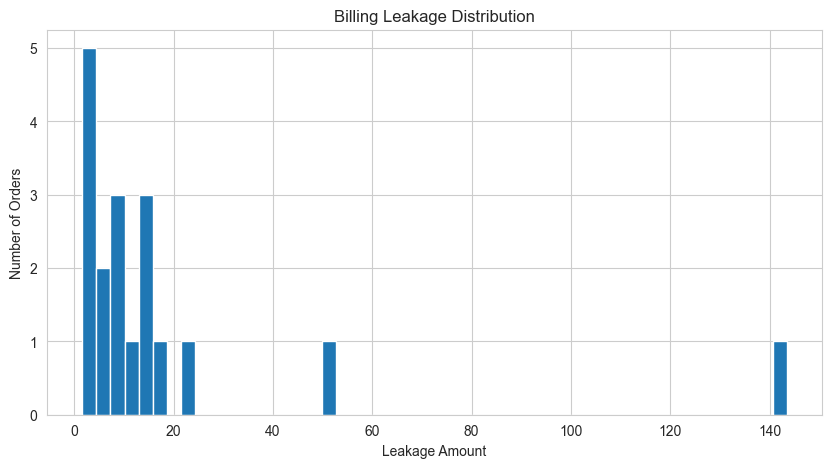

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

clean_leakage["Billing Leakage Amount"].hist(bins=50)

plt.title("Billing Leakage Distribution")
plt.xlabel("Leakage Amount")
plt.ylabel("Number of Orders")

plt.show()

In [58]:
summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Flagged Orders",
        "Total Leakage",
        "Average Leakage per Order",
        "Max Leakage Case"
    ],
    "Value": [
        len(olist_master),
        len(clean_leakage),
        clean_leakage["Billing Leakage Amount"].sum(),
        clean_leakage["Billing Leakage Amount"].mean(),
        clean_leakage["Billing Leakage Amount"].max()
    ]
})

summary

,Metric,Value
0,Total Orders,99441.000000
1,Flagged Orders,18.000000
2,Total Leakage,341.030000
3,Average Leakage per Order,18.946111
4,Max Leakage Case,143.460000


INSIGHT SUMMARY:

1. Billing system is largely accurate (low leakage ratio)
2. Leakage is concentrated in few delivered orders
3. Payment complexity (installments/single payment) increases mismatch risk
4. No evidence of systemic fraud or large-scale revenue loss
5. Observed leakage is primarily reconciliation + timing mismatch issue

RECOMMENDATIONS:

1. Improve payment reconciliation logic at order-finalization stage
2. Add real-time payment vs order validation check
3. Reduce mismatch via better payment aggregation rules
4. Monitor high-value delivered orders for anomalies
5. Focus on installment-based transactions for audit rules

In [60]:
olist_master.shape

(99441, 18)

In [61]:
# ==============================
# SQLITE CONNECTION
# ==============================

conn = sqlite3.connect(
    "../Database/revenue_leakage.db"
)

print("Connected to SQLite.")

Connected to SQLite.


In [62]:
# ==============================
# STORE OLIST MASTER TABLE
# ==============================

olist_master.to_sql(
    "olist_billing_analysis",
    conn,
    if_exists="replace",
    index=False
)

print("Olist master table stored successfully.")

Olist master table stored successfully.
